<a href="https://www.kaggle.com/code/vitorblaia/notebook9cc82e7498?scriptVersionId=350688333" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/valakhorasani/bank-transaction-dataset-for-fraud-detection/bank_transactions_data_2.csv


## Etapa 1 - Import e validação de Dataset (16/09)

In [2]:
import numpy as np
import pandas as pd
from scipy import stats
df = pd.read_csv('/kaggle/input/datasets/valakhorasani/bank-transaction-dataset-for-fraud-detection/bank_transactions_data_2.csv')
df.head

<bound method NDFrame.head of      TransactionID AccountID  TransactionAmount      TransactionDate  \
0         TX000001   AC00128              14.09  2023-04-11 16:29:14   
1         TX000002   AC00455             376.24  2023-06-27 16:44:19   
2         TX000003   AC00019             126.29  2023-07-10 18:16:08   
3         TX000004   AC00070             184.50  2023-05-05 16:32:11   
4         TX000005   AC00411              13.45  2023-10-16 17:51:24   
...            ...       ...                ...                  ...   
2507      TX002508   AC00297             856.21  2023-04-26 17:09:36   
2508      TX002509   AC00322             251.54  2023-03-22 17:36:48   
2509      TX002510   AC00095              28.63  2023-08-21 17:08:50   
2510      TX002511   AC00118             185.97  2023-02-24 16:24:46   
2511      TX002512   AC00009             243.08  2023-02-14 16:21:23   

     TransactionType          Location DeviceID      IP Address MerchantID  \
0              Debit       

In [3]:
df.info

<bound method DataFrame.info of      TransactionID AccountID  TransactionAmount      TransactionDate  \
0         TX000001   AC00128              14.09  2023-04-11 16:29:14   
1         TX000002   AC00455             376.24  2023-06-27 16:44:19   
2         TX000003   AC00019             126.29  2023-07-10 18:16:08   
3         TX000004   AC00070             184.50  2023-05-05 16:32:11   
4         TX000005   AC00411              13.45  2023-10-16 17:51:24   
...            ...       ...                ...                  ...   
2507      TX002508   AC00297             856.21  2023-04-26 17:09:36   
2508      TX002509   AC00322             251.54  2023-03-22 17:36:48   
2509      TX002510   AC00095              28.63  2023-08-21 17:08:50   
2510      TX002511   AC00118             185.97  2023-02-24 16:24:46   
2511      TX002512   AC00009             243.08  2023-02-14 16:21:23   

     TransactionType          Location DeviceID      IP Address MerchantID  \
0              Debit     

In [4]:
df.describe(include='all')

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
count,2512,2512,2512.000000,2512,2512,2512,2512,2512,2512,2512,2512.000000,2512,2512.000000,2512.000000,2512.000000,2512
unique,2512,495,NaN,2512,2,43,681,592,100,3,NaN,4,NaN,NaN,NaN,360
top,TX002496,AC00460,NaN,2023-04-03 16:07:53,Debit,Fort Worth,D000548,200.136.146.93,M026,Branch,NaN,Student,NaN,NaN,NaN,2024-11-04 08:09:17
freq,1,12,NaN,1,1944,70,9,13,45,868,NaN,657,NaN,NaN,NaN,16
mean,NaN,NaN,297.593778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.673965,NaN,119.643312,1.124602,5114.302966,NaN
std,NaN,NaN,291.946243,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.792198,NaN,69.963757,0.602662,3900.942499,NaN
min,NaN,NaN,0.260000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.000000,NaN,10.000000,1.000000,101.250000,NaN
25%,NaN,NaN,81.885000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.000000,NaN,63.000000,1.000000,1504.370000,NaN
50%,NaN,NaN,211.140000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.000000,NaN,112.500000,1.000000,4735.510000,NaN
75%,NaN,NaN,414.527500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59.000000,NaN,161.000000,1.000000,7678.820000,NaN


In [5]:
df.isnull().sum()

TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64

## Definição de variável alvo (fraude)
Definimos uma heurística multissinal:
transação é marcada como potencial fraude quando pelo menos 2 dos 3 critérios
ocorrem simultaneamente
valor da transação anômalo (|z-score| > 2), volume
elevado de tentativas de login (top 5%), ou duração de transação atípica
(|z-score| > 2). Essa abordagem reduz falsos positivos de uma heurística
baseada em uma única variável e se aproxima de práticas reais de scoring de
risco (combinação de múltiplos indicadores).

In [6]:
df['amount_zscore'] = stats.zscore(df['TransactionAmount'])
df['high_login_attempts'] = (df['LoginAttempts'] > df['LoginAttempts'].quantile(0.95))
duration_zscore = stats.zscore(df['TransactionDuration'])
df['is_fraud'] = (
    (df['amount_zscore'].abs() > 2).astype(int) + 
    df['high_login_attempts'] + 
    (np.abs(duration_zscore) > 2).astype(int)
) >=2
df['is_fraud'] = df['is_fraud'].astype(int)
df['is_fraud'].value_counts()

is_fraud
0    2491
1      21
Name: count, dtype: int64

In [7]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(cat_cols)

['TransactionID', 'AccountID', 'TransactionDate', 'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID', 'Channel', 'CustomerOccupation', 'PreviousTransactionDate']


In [8]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['transaction_hour'] = df['TransactionDate'].dt.hour
df['transaction_dayofweek'] = df['TransactionDate'].dt.dayofweek

date_cols = ['TransactionDate', 'PreviousTransactionDate']
extra_id_cols = ['IP Address']

id_like_cols = [c for c in cat_cols if 'ID' in c or 'Id' in c] + extra_id_cols
cat_cols_to_encode = [c for c in cat_cols if c not in id_like_cols and c not in date_cols]



df_encoded = pd.get_dummies(df,columns= cat_cols_to_encode, drop_first=True)
df_encoded = df_encoded.drop(columns= id_like_cols +date_cols, errors='ignore')

df_encoded.head()
df_encoded.shape

(2512, 58)

## Etapa 2 - Divisão dos dados de teste e treino, aplicação do Gridsearchcv e treino do modelo com teste.

(2009, 55) (503, 55)
is_fraud
0    1992
1      17
Name: count, dtype: int64
is_fraud
0    499
1      4
Name: count, dtype: int64
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Melhores parametros: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Melhor f1(validacao): 0.297979797979798
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       499
           1       0.25      0.75      0.38         4

    accuracy                           0.98       503
   macro avg       0.62      0.87      0.68       503
weighted avg       0.99      0.98      0.99       503



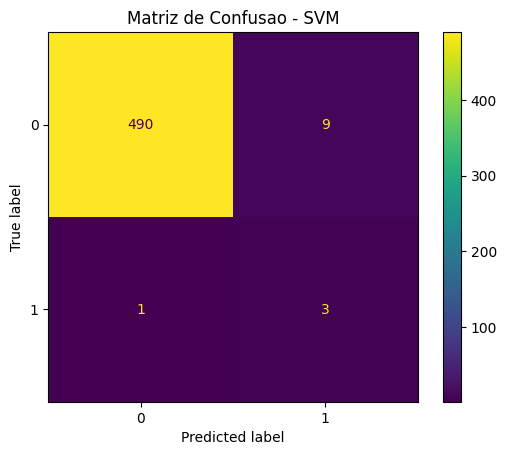

In [9]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

x = df_encoded.drop(columns=['is_fraud','amount_zscore','high_login_attempts'],errors='ignore')
y = df_encoded['is_fraud']

x_train, x_test, y_train, y_test = train_test_split(
    x,y,test_size=0.2,random_state=42,stratify=y
)

print(x_train.shape,x_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


param_grid = {
    'C':[0.1,1,10] ,
    'kernel':['linear','rbf'],
    'gamma': ['scale','auto']
}

cv = StratifiedKFold(n_splits=5, shuffle=True,random_state=42)
grid= GridSearchCV(
    SVC(class_weight='balanced'),
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid.fit(x_train_scaled,y_train)

print("Melhores parametros:",grid.best_params_)
print("Melhor f1(validacao):",grid.best_score_)

best_model = grid.best_estimator_
y_pred = best_model.predict(x_test_scaled)

print(classification_report(y_test,y_pred))

cm = confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Matriz de Confusao - SVM")
plt.show()